In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


In [ ]:
acled_data = pd.read_csv('../../data/raw/features/ACLED_2018.csv')
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-11-13.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

,adm2,energy_kcal_q50,energy_kcal_q50_se,ca_mg_q50,ca_mg_q50_se,mg_mg_q50,mg_mg_q50_se,fe_mg_q50,fe_mg_q50_se,zn_mg_q50,zn_mg_q50_se,thia_mg_q50,thia_mg_q50_se,ribo_mg_q50,ribo_mg_q50_se,niac_mg_q50,niac_mg_q50_se,vitb6_mg_q50,vitb6_mg_q50_se,vitc_mg_q50,vitc_mg_q50_se,protein_g_q50,protein_g_q50_se,fat_g_q50,fat_g_q50_se,carbohydrate_g_q50,carbohydrate_g_q50_se,fibre_g_q50,fibre_g_q50_se,starch_g_q50,starch_g_q50_se,cholesterol_g_q50,cholesterol_g_q50_se,vitb12_mcg_q50,vitb12_mcg_q50_se,folate_mcg_q50,folate_mcg_q50_se,vita_rae_mcg_q50,vita_rae_mcg_q50_se,vite_mcg_q50,vite_mcg_q50_se,vita_inad,vita_inad_se,zn_inad,zn_inad_se,folate_inad,folate_inad_se,thia_inad,thia_inad_se,vitb12_inad,vitb12_inad_se,fe_inad
0,11,1872.295308,16.663122,455.731880,5.361542,154.431177,1.921288,9.896127,0.098297,7.568138,0.089987,0.839178,0.008099,0.698174,0.009018,8.593633,0.077278,0.922176,0.010504,30.568625,0.590619,57.226472,0.572817,54.451936,0.577463,283.605398,2.969200,22.566615,0.256190,33.403371,0.925754,53.704273,0.817782,1.164260,0.025778,187.127905,2.101151,193.781450,3.002329,0,0,97.320387,4.146648e-01,87.183507,0.860197,81.844796,1.073947,59.743869,1.385496,82.238117,1.045527,78.957650
1,12,1922.323669,20.501485,428.136241,7.211011,159.544137,1.875397,9.980315,0.123978,7.595581,0.085291,0.830605,0.008831,0.678448,0.010631,8.579428,0.115876,0.928178,0.012507,28.096760,0.552301,57.193420,0.751221,57.513990,0.886260,292.665477,3.574873,23.459890,0.385958,33.739402,1.239502,53.211816,1.054739,1.146311,0.026251,192.662570,2.566671,167.079039,3.486096,0,0,97.819662,4.377599e-01,83.642204,1.129257,76.056013,1.325401,60.666974,1.516520,83.836805,1.092432,77.445997
2,13,2018.012131,25.072159,391.913361,6.620504,166.280214,2.012130,9.759941,0.122473,8.128786,0.084404,0.880784,0.011179,0.633975,0.008265,8.757214,0.110400,0.905884,0.015334,26.339418,0.694576,59.554939,0.697222,52.173867,0.966256,323.975313,3.702305,23.750113,0.275743,27.060978,1.218638,52.055012,1.200573,1.151607,0.027784,189.665231,3.061989,157.505846,4.857071,0,0,97.949489,4.185460e-01,80.529370,1.404218,81.121433,1.428539,53.115583,1.761463,84.157322,1.215177,79.818891
3,21,1916.842844,30.831254,363.561476,8.933607,134.063044,2.483684,8.812968,0.134932,7.307671,0.110290,0.814289,0.011775,0.585011,0.010866,7.596644,0.108397,0.866459,0.014561,28.659533,0.884897,51.656248,0.676101,52.974234,0.896040,299.257292,3.682766,22.117777,0.288167,20.383647,0.900236,49.303612,1.356933,0.865130,0.030076,164.180752,3.417583,153.483332,3.811203,0,0,98.173099,3.631053e-01,88.947145,0.890745,85.651582,1.175243,63.710986,1.779443,91.988356,0.873882,84.891473
4,22,1947.599994,52.394253,334.792754,9.409328,138.928448,3.897140,8.871641,0.178795,7.463490,0.179548,0.817896,0.017990,0.563490,0.018488,7.590853,0.191473,0.892218,0.024907,27.112383,0.856691,51.656840,1.106016,57.416403,1.282071,306.093231,7.580420,23.140606,0.530619,17.736180,1.335717,46.526549,1.716528,0.847131,0.035430,165.026210,4.608217,124.301714,3.674439,0,0,98.359475,5.416011e-01,81.612731,1.816827,84.983630,1.560577,61.645237,2.354747,88.854730,1.332794,82.389351
5,23,2008.120260,40.317898,307.949590,11.281918,124.182982,3.765478,9.354087,0.260359,7.396211,0.139329,0.864749,0.016401,0.558956,0.013074,7.687323,0.173554,0.843057,0.017460,23.092957,1.014487,53.368189,1.218249,47.634643,1.666735,330.993262,6.476984,22.789088,0.517160,15.207164,1.332809,70.715572,3.346230,0.758911,0.038545,159.778872,3.697482,122.223561,5.085085,0,0,98.541107,4.265682e-01,81.739948,1.722187,86.898868,1.451075,54.184541,2.363716,94.026034,0.973012,81.146245
6,31,1929.539386,27.153221,399.107524,9.766792,167.690351,3.428110,9.696052,0.176992,8.007232,0.135969,0.834064,0.010688,0.645740,0.012302,8.494925,0.136802,0.877791,0.017018,25.440797,0.655877,58.678339,0.786414,52.893303,0.971895,300.698488,4.307745,24.107135,0.445038,24.606765,1.349150,51.966682,1.523523,1.305644,0.041280,184.214123,4.369066,154.079051,4.021990,0,0,97.312984,4.517862e-01,75.524

In [ ]:
acled_data['event_date'] = pd.to_datetime(acled_data['event_date'], format='%Y-%m-%d')
acled_data['event_month'] = acled_data['event_date'].dt.month
acled_data
# count the number of events per month 
# acled_data.groupby('event_month')
acled_counts2018 = acled_data[['event_month','admin2']].value_counts()
acled_counts2018 = pd.DataFrame(acled_counts2018).reset_index()
acled_counts2018

,event_month,admin2,count
0,11,Colombo,26
1,12,Colombo,25
2,9,Colombo,18
3,10,Colombo,17
4,7,Colombo,15
...,...,...,...
143,7,Anuradhapura,1
144,6,Kalutara,1
145,6,Jaffna,1
146,5,Ratnapura,1


In [ ]:
# look at types of acled variable
 
acled_data['interaction'].unique()
acled_data['admin2'].unique()

array(['Nuwara Eliya', 'Colombo', 'Mannar', 'Hambantota', 'Vavuniya', 'Kegalle',
       'Moneragala', 'Badulla', 'Anuradhapura', 'Galle', 'Jaffna', 'Kalutara',
       'Batticaloa', 'Gampaha', 'Puttalam', 'Kandy', 'Kilinochchi', 'Matara', 'Matale',
       'Mullaitivu', 'Ratnapura', 'Kurunegala', 'Polonnaruwa', 'Trincomalee', 'Ampara'],
      dtype=object)

In [ ]:

def merge_district_codes(df):
    # District code mapping
    districts = [
        {"adm2": 81, "admin2": "Badulla"}, {"adm2": 11, "admin2": "Colombo"},
        {"adm2": 12, "admin2": "Gampaha"}, {"adm2": 41, "admin2": "Jaffna"},
        {"adm2": 13, "admin2": "Kalutara"}, {"adm2": 21, "admin2": "Kandy"},
        {"adm2": 92, "admin2": "Kegalle"}, {"adm2": 61, "admin2": "Kurunegala"},
        {"adm2": 43, "admin2": "Mannar"}, {"adm2": 22, "admin2": "Matale"},
        {"adm2": 82, "admin2": "Moneragala"}, {"adm2": 23, "admin2": "Nuwara Eliya"},
        {"adm2": 72, "admin2": "Polonnaruwa"}, {"adm2": 91, "admin2": "Ratnapura"},
        {"adm2": 53, "admin2": "Trincomalee"}, {"adm2": 44, "admin2": "Vavuniya"},
        {"adm2": 71, "admin2": "Anuradhapura"}, {"adm2": 44, "admin2": "Mullaitivu"},
        {"adm2": 52, "admin2": "Ampara"},{"adm2":52, "admin2": "Batticaloa"},
        {"adm2": 33, "admin2": "Hambantota"}, {"adm2": 45, "admin2": "Kilinochchi"},
        {"adm2": 62, "admin2": "Puttalam"}, {"adm2": 31, "admin2": "Galle"},
        {"adm2": 32, "admin2": "Matara"}
        
    ]
    
    df_districts = pd.DataFrame(districts)
    
    # Merge to assign adm2 codes
    merged = df.merge(df_districts, on='admin2', how='left')
    
    return merged


matched_data = merge_district_codes(acled_counts2018)

matched_data

,event_month,admin2,count,adm2
0,11,Colombo,26,11
1,12,Colombo,25,11
2,9,Colombo,18,11
3,10,Colombo,17,11
4,7,Colombo,15,11
...,...,...,...,...
143,7,Anuradhapura,1,71
144,6,Kalutara,1,13
145,6,Jaffna,1,41
146,5,Ratnapura,1,91


In [59]:
matched_data_hm = matched_data.pivot(index="event_month", columns="admin2", values="count").fillna(0)

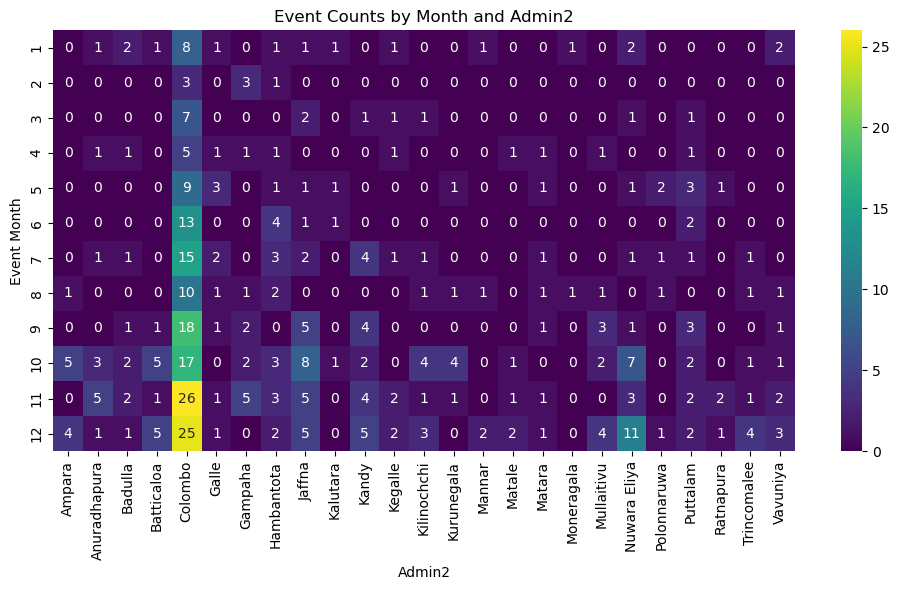

In [60]:


plt.figure(figsize=(10, 6))
sns.heatmap(matched_data_hm, cmap="viridis", annot=True, fmt=".0f")
plt.title("Event Counts by Month and Admin2")
plt.xlabel("Admin2")
plt.ylabel("Event Month")
plt.tight_layout()
plt.show()



In [101]:
ml_targets = ml_targets.merge(hh_info)


ml_targets = ml_targets.groupby(["adm2", "month"]).agg({
        'folate_mcg': 'mean',
        'fe_mg': 'mean',
        'zn_mg': 'mean',
        'vita_rae_mcg':'mean',
        'overall_mar': 'mean'
    }).reset_index()


In [102]:
ml_targets

,adm2,month,folate_mcg,fe_mg,zn_mg,vita_rae_mcg,overall_mar
0,11,1,195.486241,10.250826,7.897227,195.032183,0.644770
1,11,2,188.846213,10.207112,7.524377,209.926474,0.649025
2,11,3,189.747654,10.090100,7.517747,201.606852,0.644933
3,11,4,183.054480,9.713302,7.294007,218.429957,0.633308
4,11,5,188.761248,9.985803,7.539969,209.002125,0.630502
...,...,...,...,...,...,...,...
295,92,8,183.221369,8.875114,7.514673,180.855478,0.587409
296,92,9,173.910791,8.296079,7.224668,140.746275,0.543205
297,92,10,198.654319,9.627478,7.758611,153.686605,0.615932
298,92,11,181.826600,8.950647,7.650771,149.503288,0.577109


In [104]:
matched_data.rename(columns={'event_month': 'month'}, inplace=True)
matched_data
adm2_season = ml_targets.merge(matched_data, on= ['adm2','month'])
adm2_season

,adm2,month,folate_mcg,fe_mg,zn_mg,vita_rae_mcg,overall_mar,admin2,count
0,11,1,195.486241,10.250826,7.897227,195.032183,0.644770,Colombo,8
1,11,2,188.846213,10.207112,7.524377,209.926474,0.649025,Colombo,3
2,11,3,189.747654,10.090100,7.517747,201.606852,0.644933,Colombo,7
3,11,4,183.054480,9.713302,7.294007,218.429957,0.633308,Colombo,5
4,11,5,188.761248,9.985803,7.539969,209.002125,0.630502,Colombo,9
...,...,...,...,...,...,...,...,...,...
143,92,3,180.634707,9.157141,7.660387,146.427268,0.586925,Kegalle,1
144,92,4,202.140703,9.825817,8.494955,171.690588,0.633152,Kegalle,1
145,92,7,181.161052,9.695647,7.854098,158.531772,0.607550,Kegalle,1
146,92,11,181.826600,8.950647,7.650771,149.503288,0.577109,Kegalle,2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


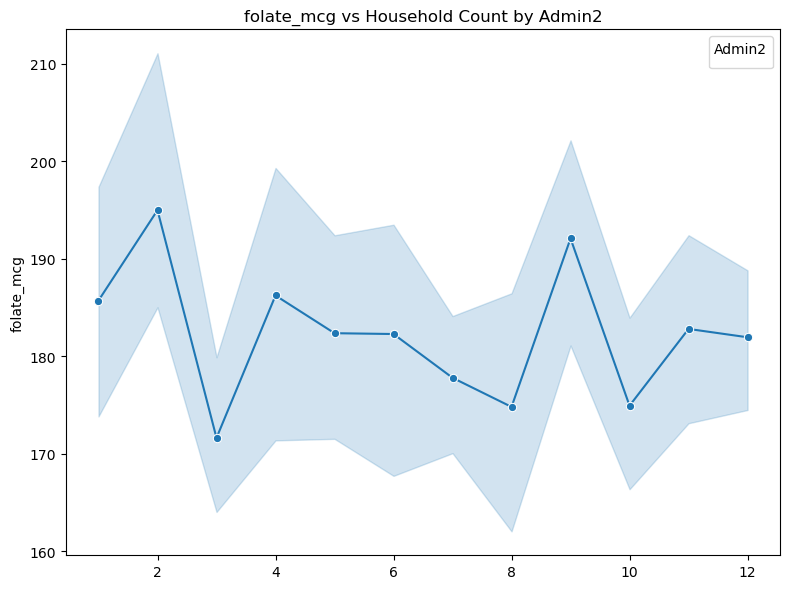

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


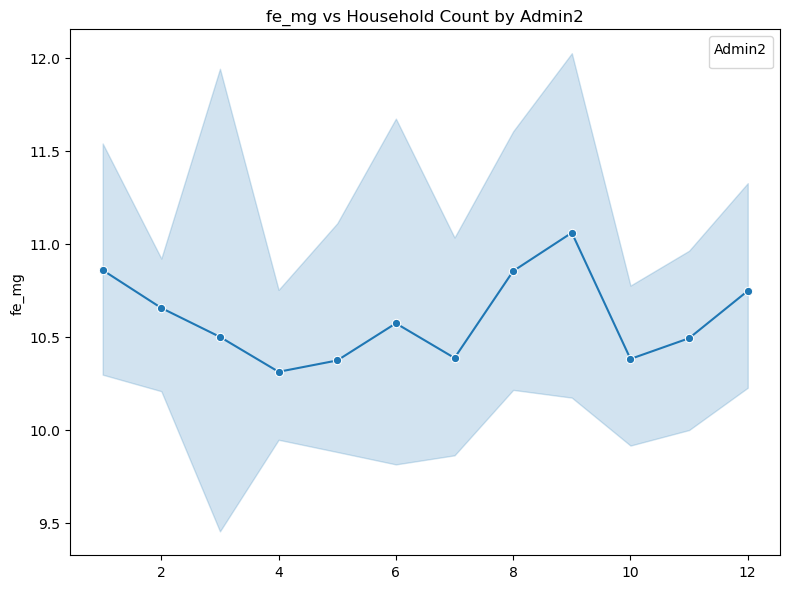

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


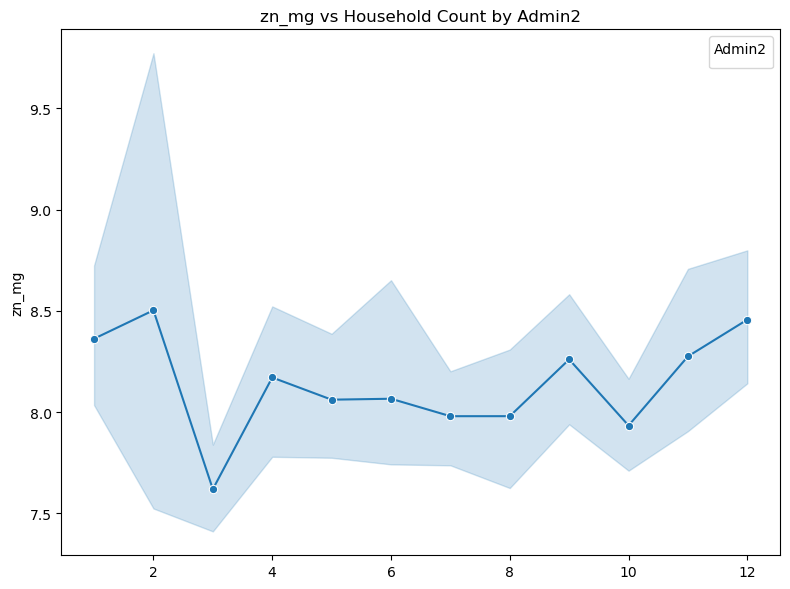

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


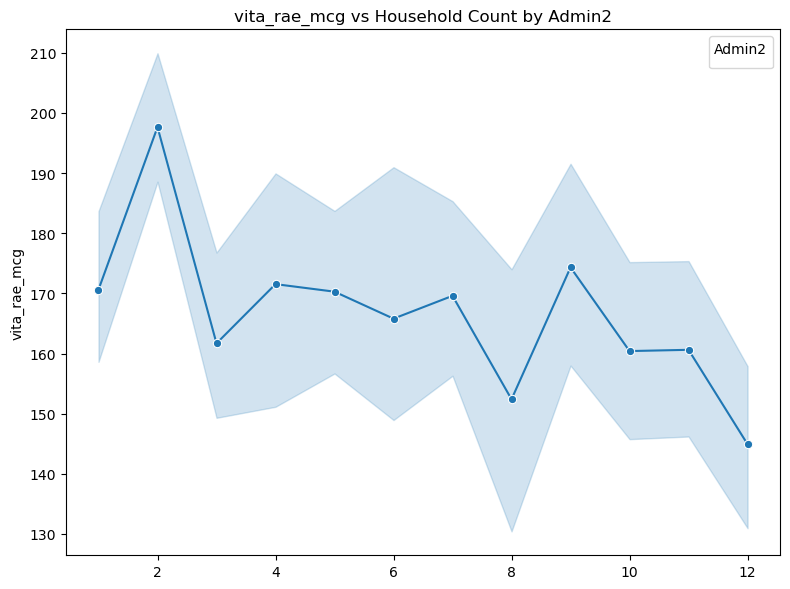

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


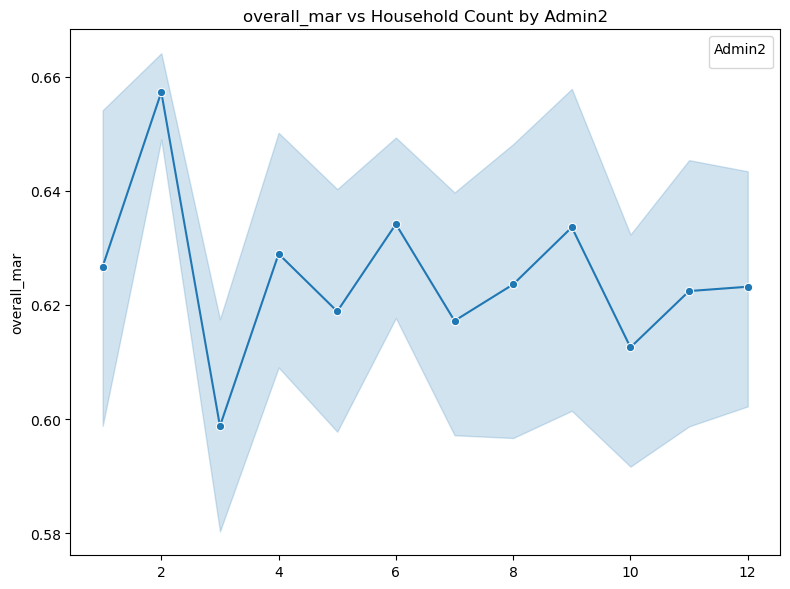

In [ ]:


# List of nutrients to plot
nutrients = ['folate_mcg', 'fe_mg', 'zn_mg','vita_rae_mcg', 'overall_mar']

# Loop through each nutrient and create a scatter plot
for nutrient in nutrients:
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=adm2_season, x='month', y=nutrient,
    #  hue='admin2',
      marker = 'o')
    plt.title(f'{nutrient} ovre time')
    plt.xlabel('')
    plt.ylabel(nutrient)
    plt.legend(title='Admin2')
    plt.tight_layout()
    plt.show()



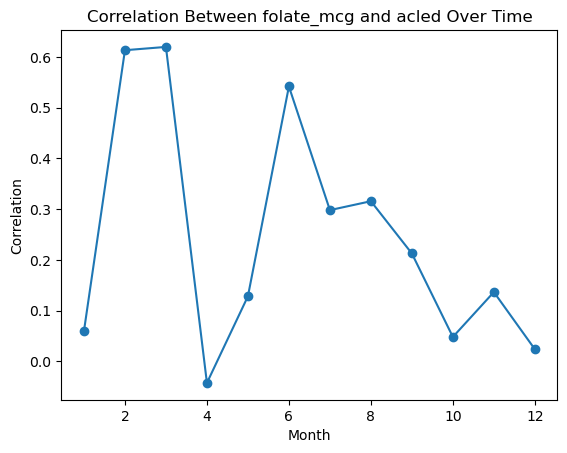

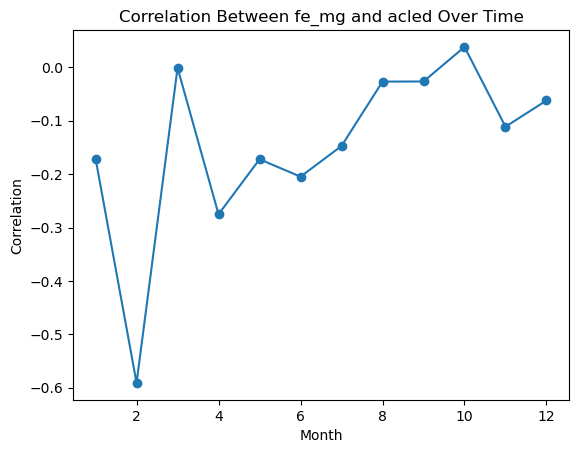

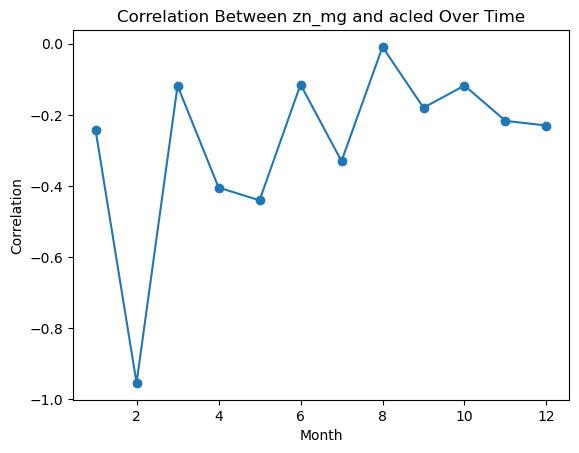

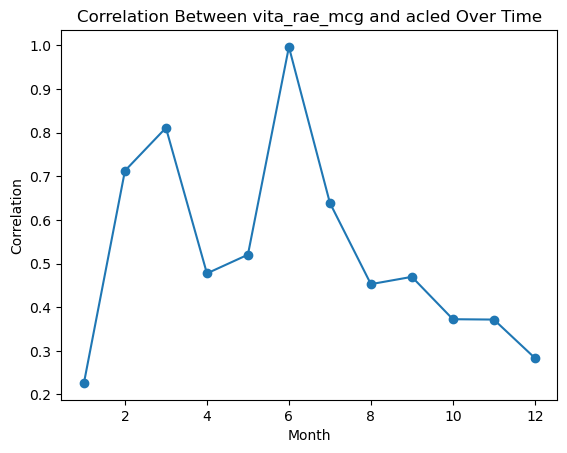

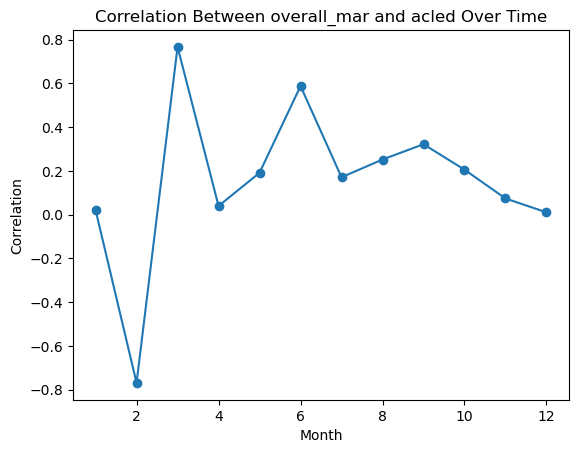

In [111]:
for nutrient in nutrients:
    corr_by_month = adm2_season.groupby('month')[[nutrient, 'count']].corr().unstack().iloc[:,1]
    corr_by_month.plot(kind='line', marker='o')
    plt.title(f'Correlation Between {nutrient} and acled Over Time')
    plt.xlabel('Month')
    plt.ylabel('Correlation')
    plt.show()
